In [95]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
project_path = projectpath = r'G:\XJN_M2project'
model = 'test2'
group = 'depressed' 
condition = 'rescue'  # 'pre', 'post', 'rescue'
condition_dir = os.path.join(project_path, 'signal_data', model, condition)
mice_ids = [f for f in os.listdir(condition_dir) if os.path.isdir(os.path.join(condition_dir, f)) and f != 'group']

activity_threshold = 1.5  # z>1.5 as event
record_time = 1  # seconds per sample/frame
cmap = 'RdBu_r'
jaccard_cmap = 'viridis'

include_diagonal_in_pairwise_mean = True  # matches the original STS summary behavior: np.triu_indices(n, k=0)
preview_neuron_index = 0
preview_max_events = 20


## Helper: correlation index

`correlation_index` follows the original notebook logic. It counts simultaneous active frames in two binary activity vectors, subtracts the expected coincidence under independent activity, and normalizes by `min(N_i, N_j) - N_expected`. If the denominator is zero, the value is undefined; this notebook falls back to `0.0` and prints a message when verbose mode is enabled.


In [97]:
def correlation_index(spikes_i, spikes_j, verbose=False):
    spikes_i = np.asarray(spikes_i).astype(bool)
    spikes_j = np.asarray(spikes_j).astype(bool)

    if spikes_i.shape != spikes_j.shape:
        raise ValueError('spikes_i and spikes_j must have the same shape')

    T = len(spikes_i)
    if T == 0:
        if verbose:
            print('Fallback: empty vectors in correlation_index; returning 0.0')
        return 0.0

    N_i = spikes_i.sum()
    N_j = spikes_j.sum()
    N_expected = (N_i * N_j) / T
    N_coinc = np.logical_and(spikes_i, spikes_j).sum()

    denominator = min(N_i, N_j) - N_expected
    if denominator == 0:
        if verbose:
            print('Fallback: zero denominator in correlation_index; returning 0.0')
        return 0.0

    Ci = (N_coinc - N_expected) / denominator
    return float(np.clip(Ci, -1, 1))


## Helper: Jaccard similarity index

For two binary calcium activity vectors, the Jaccard similarity index is computed as:

`J = M11 / (M10 + M01 + M11)`

where `M11` is the number of frames where both neurons are active, and `M10` / `M01` are frames where only one neuron is active. This measures coactivity in binarized calcium signals without assuming high-frequency spike timing. If neither neuron is active in either vector, the union is zero; this notebook falls back to `0.0` and prints a message when verbose mode is enabled.


In [98]:
def jaccard_similarity_index(activity_i, activity_j, verbose=False):
    activity_i = np.asarray(activity_i).astype(bool)
    activity_j = np.asarray(activity_j).astype(bool)

    if activity_i.shape != activity_j.shape:
        raise ValueError('activity_i and activity_j must have the same shape')

    intersection = np.logical_and(activity_i, activity_j).sum()
    union = np.logical_or(activity_i, activity_j).sum()

    if union == 0:
        if verbose:
            print('Fallback: zero union in jaccard_similarity_index; returning 0.0')
        return 0.0

    return float(intersection / union)


def compute_jaccard_matrix(binary_data, verbose=False):
    n_neurons = binary_data.shape[1]
    jaccard_mat = np.zeros((n_neurons, n_neurons), dtype=float)

    for i in range(n_neurons):
        for j in range(i, n_neurons):
            if i == j:
                jaccard_mat[i, j] = 1.0
            else:
                value = jaccard_similarity_index(
                    binary_data.iloc[:, i].values,
                    binary_data.iloc[:, j].values,
                    verbose=verbose,
                )
                jaccard_mat[i, j] = value
                jaccard_mat[j, i] = value

    return jaccard_mat


def upper_triangle_mean(matrix, include_diagonal=True):
    k = 0 if include_diagonal else 1
    values = matrix[np.triu_indices(matrix.shape[0], k=k)]
    if values.size == 0:
        print('Fallback: no upper-triangle values available; returning np.nan')
        return np.nan
    return float(np.nanmean(values))


def upper_triangle_quantile(matrix, q=0.90, include_diagonal=False):
    k = 0 if include_diagonal else 1
    values = matrix[np.triu_indices(matrix.shape[0], k=k)]
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(f'Fallback: no finite upper-triangle values available for q={q}; returning np.nan')
        return np.nan
    return float(np.nanquantile(values, q))


## Main run

This section preserves the original saving structure:

- per mouse output: `correlation_analysis/{model}/{condition}/{miceID}/`
- group summary output: `correlation_analysis/{model}/{condition}/group/{group}/`

The STS matrix from the original notebook is replaced by a Jaccard similarity matrix calculated from `binary_data = (TST_data > activity_threshold).astype(int)`.


File not found: G:\XJN_M2project\signal_data\test2\rescue\CSDS0087\signal_save\CSDS0087_rescue_all_cell_table_TST.csv, skipping CSDS0087
File not found: G:\XJN_M2project\signal_data\test2\rescue\CSDS0126\signal_save\CSDS0126_rescue_all_cell_table_TST.csv, skipping CSDS0126
Processing CSDS5776 - rescue
Binarized calcium activity for CSDS5776 - rescue with threshold Z > 1.5
Computed binary activity event times for 51 neurons.
Example activity times for neuron 0: [60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79] ...
Average Jaccard similarity for CSDS5776 - rescue: 0.0924
Q90 Jaccard similarity for CSDS5776 - rescue: 0.1371


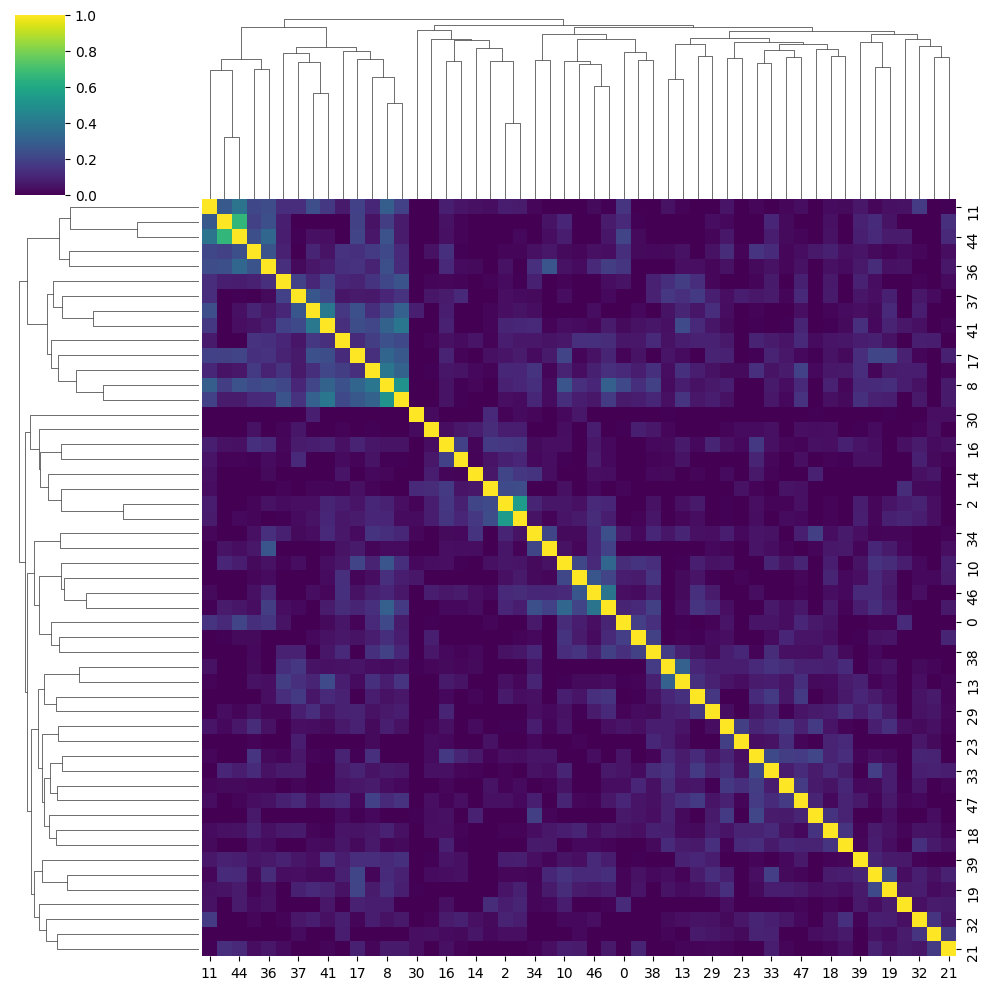

Processing CSDS5797 - rescue
Binarized calcium activity for CSDS5797 - rescue with threshold Z > 1.5
Computed binary activity event times for 51 neurons.
Example activity times for neuron 0: [184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203] ...
Average Jaccard similarity for CSDS5797 - rescue: 0.0831
Q90 Jaccard similarity for CSDS5797 - rescue: 0.1225


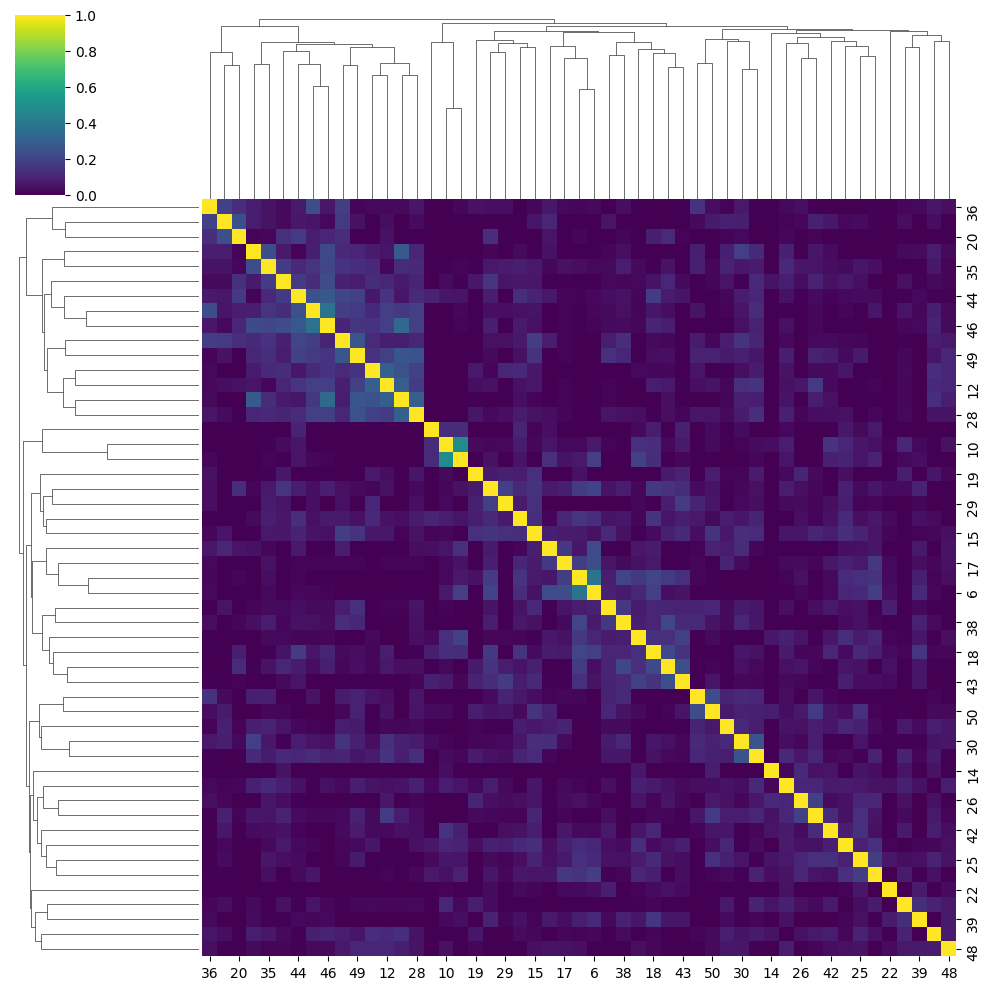

Processing CSDSQ26 - rescue
Binarized calcium activity for CSDSQ26 - rescue with threshold Z > 1.5
Computed binary activity event times for 54 neurons.
Example activity times for neuron 0: [629, 630, 631, 632, 633, 634, 635, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 1014, 1015] ...
Average Jaccard similarity for CSDSQ26 - rescue: 0.0790
Q90 Jaccard similarity for CSDSQ26 - rescue: 0.1383


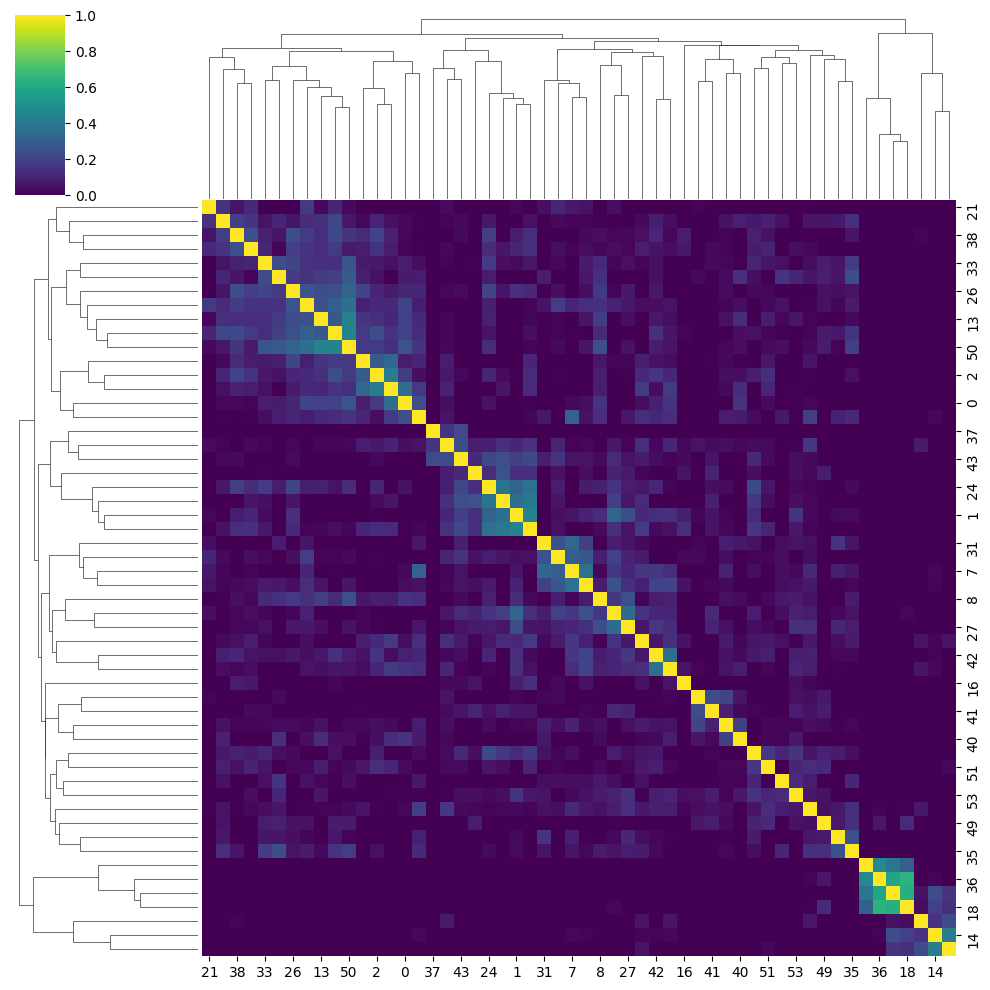

File not found: G:\XJN_M2project\signal_data\test2\rescue\LH0167\signal_save\LH0167_rescue_all_cell_table_TST.csv, skipping LH0167
Processing LHQ30 - rescue
Binarized calcium activity for LHQ30 - rescue with threshold Z > 1.5
Computed binary activity event times for 109 neurons.
Example activity times for neuron 0: [1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960] ...
Average Jaccard similarity for LHQ30 - rescue: 0.0648
Q90 Jaccard similarity for LHQ30 - rescue: 0.1277


c:\ProgramData\miniconda3\envs\conda_global\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\ProgramData\miniconda3\envs\conda_global\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


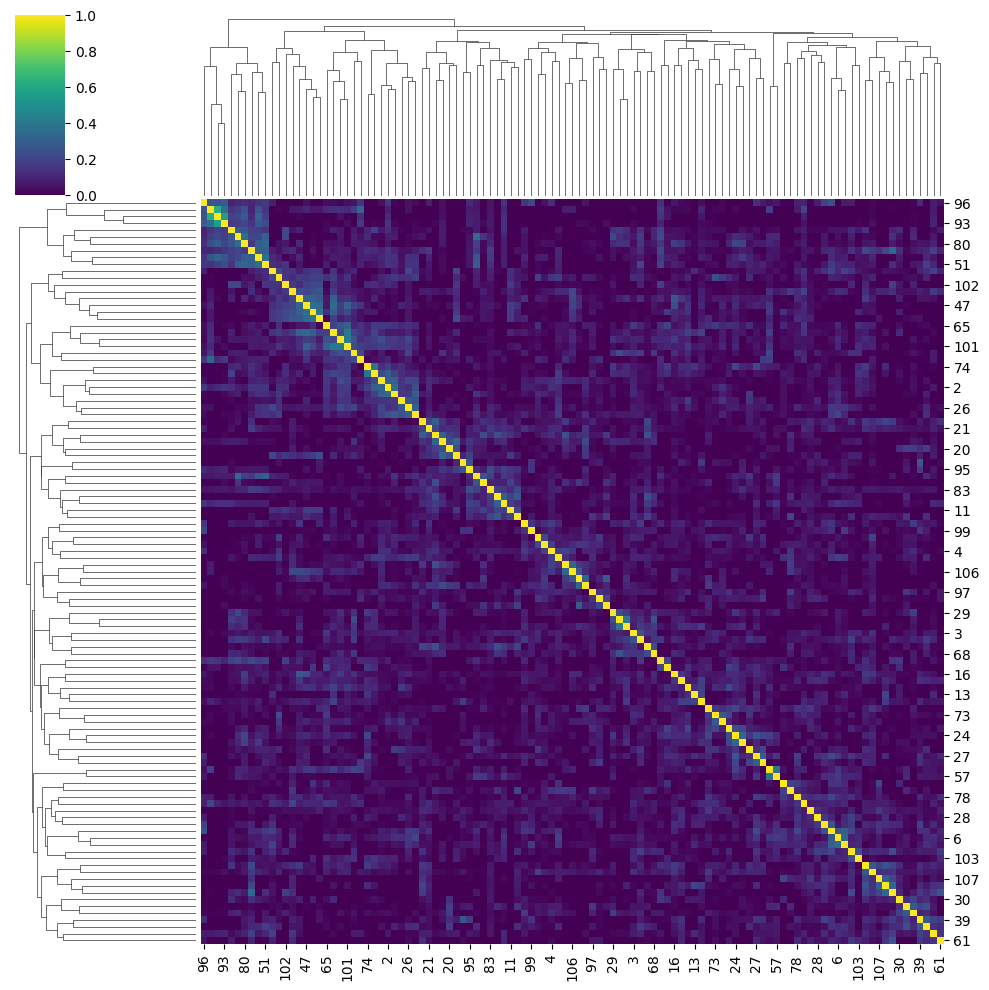

Processing LHQ50 - rescue
Binarized calcium activity for LHQ50 - rescue with threshold Z > 1.5
Computed binary activity event times for 22 neurons.
Example activity times for neuron 0: [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49] ...
Average Jaccard similarity for LHQ50 - rescue: 0.1283
Q90 Jaccard similarity for LHQ50 - rescue: 0.1294


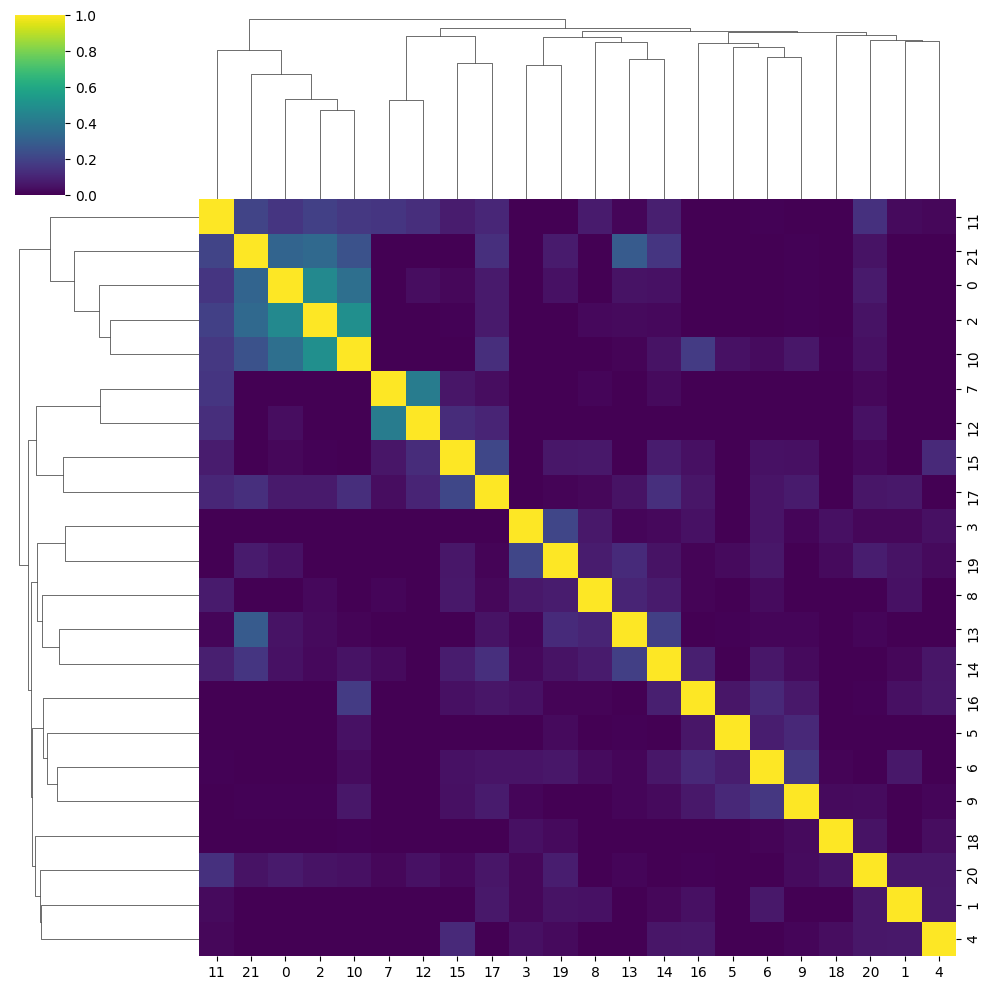

Processing LH5798 - rescue
Binarized calcium activity for LH5798 - rescue with threshold Z > 1.5
Computed binary activity event times for 16 neurons.
Example activity times for neuron 0: [27, 28, 29, 30, 31, 32, 33, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81] ...
Average Jaccard similarity for LH5798 - rescue: 0.1598
Q90 Jaccard similarity for LH5798 - rescue: 0.1346


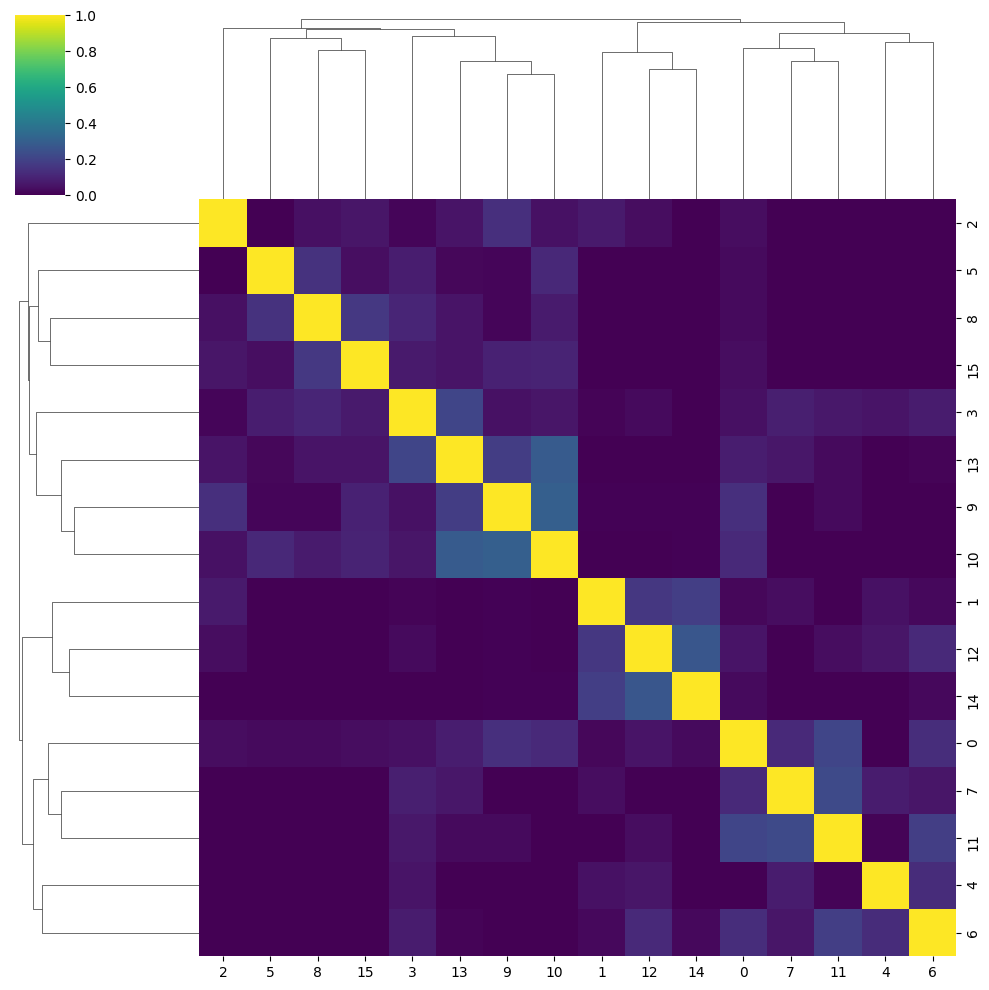

Finished. Saved group summary to: G:\XJN_M2project\correlation_analysis\test2\rescue\group\depressed
Processed mice: 6
Skipped mice: 3


In [ ]:
KNN_accuracy_df = pd.DataFrame(columns=['2D Accuracy', '3D Accuracy'])
all_mice_MSTM_matrices = []
skipped_mice = []
last_preview = None

for miceID in mice_ids:
    VERBOSE = miceID == mice_ids[0]
    signal_path_TST_align = os.path.join(
        projectpath,
        'signal_data',
        model,
        condition,
        miceID,
        'signal_save',
        f'{miceID}_{condition}_all_cell_table_TST.csv',
    )
    mice_out = os.path.join(projectpath, 'correlation_analysis', model, condition, miceID)
    os.makedirs(mice_out, exist_ok=True)

    if not os.path.exists(signal_path_TST_align):
        reason = f'File not found: {signal_path_TST_align}'
        print(f'{reason}, skipping {miceID}')
        skipped_mice.append({'miceID': miceID, 'reason': reason})
        continue

    print(f'Processing {miceID} - {condition}')
    TST_data = pd.read_csv(signal_path_TST_align)

    if TST_data.empty:
        reason = 'TST_data is empty'
        print(f'{reason}, skipping {miceID}')
        skipped_mice.append({'miceID': miceID, 'reason': reason})
        continue

    n_neurons = TST_data.shape[1]
    if n_neurons < 1:
        reason = 'No neuron columns found'
        print(f'{reason}, skipping {miceID}')
        skipped_mice.append({'miceID': miceID, 'reason': reason})
        continue

    T = TST_data.shape[0]
    time_axis = np.arange(T) * record_time

    # plt.figure(figsize=(10, 4))
    # plt.imshow(TST_data.T, aspect='auto', cmap='coolwarm')
    # plt.title(f'Z-scored Calcium Activity for {miceID} - {condition}')
    # plt.xlabel('Time bin')
    # plt.ylabel('Neuron')
    # plt.colorbar(label='Z value')
    # plt.show()

    binary_data = (TST_data > activity_threshold).astype(int)

    # plt.figure(figsize=(10, 4))
    # plt.imshow(binary_data.T, aspect='auto', cmap='gray_r')
    # plt.title(f'Binarized Calcium Activity for {miceID} - {condition}')
    # plt.xlabel('Time bin')
    # plt.ylabel('Neuron')
    # plt.show()
    print(f'Binarized calcium activity for {miceID} - {condition} with threshold Z > {activity_threshold}')

    spike_trains = []
    for neuron in binary_data.columns:
        active_series = binary_data[neuron].values
        active_indices = np.where(active_series == 1)[0]
        active_times = time_axis[active_indices]
        spike_trains.append(active_times.tolist())

    if len(spike_trains) > 0:
        example_events = spike_trains[min(preview_neuron_index, len(spike_trains) - 1)][:preview_max_events]
        print(f'Computed binary activity event times for {len(spike_trains)} neurons.')
        print(f'Example activity times for neuron {preview_neuron_index}: {example_events} ...')

    jaccard_matrix = compute_jaccard_matrix(binary_data, verbose=VERBOSE)
    jaccard_average = upper_triangle_mean(
        jaccard_matrix,
        include_diagonal=include_diagonal_in_pairwise_mean,
    )
    q90_jaccard_similarity = upper_triangle_quantile(
        jaccard_matrix,
        q=0.90,
        include_diagonal=False,
    )

    # plt.figure(figsize=(6, 5))
    # plt.imshow(jaccard_matrix, aspect='auto', cmap=jaccard_cmap, vmin=0, vmax=1)
    # plt.title(f'Jaccard Similarity Matrix for {miceID} - {condition}')
    # plt.colorbar(label='Jaccard similarity')
    # plt.show()

    jaccard_matrix_df = pd.DataFrame(jaccard_matrix, index=TST_data.columns, columns=TST_data.columns)
    jaccard_matrix_df.to_csv(os.path.join(mice_out, f'{miceID}_{condition}_jaccard_similarity_matrix.csv'))
    print(f'Average Jaccard similarity for {miceID} - {condition}: {jaccard_average:.4f}')
    print(f'Q90 Jaccard similarity for {miceID} - {condition}: {q90_jaccard_similarity:.4f}')

    Ci_matrix = np.zeros((n_neurons, n_neurons), dtype=float)
    for i in range(n_neurons):
        for j in range(i + 1, n_neurons):
            ci = correlation_index(binary_data.iloc[:, i].values, binary_data.iloc[:, j].values, verbose=VERBOSE)
            Ci_matrix[i, j] = ci
            Ci_matrix[j, i] = ci

    ci_df = pd.DataFrame(Ci_matrix, index=TST_data.columns, columns=TST_data.columns)
    ci_df.to_csv(os.path.join(mice_out, f'{miceID}_{condition}_correlation_index_matrix.csv'))
    mean_ci = upper_triangle_mean(Ci_matrix, include_diagonal=include_diagonal_in_pairwise_mean)

    # plt.figure(figsize=(6, 5))
    # plt.title(f'Correlation Index Matrix for {miceID} - {condition} Average CI: {mean_ci:.4f}')
    # plt.imshow(ci_df, aspect='auto', cmap='viridis')
    # plt.colorbar(label='Correlation index')
    # plt.show()

    cluster_map = sns.clustermap(jaccard_matrix, cmap=jaccard_cmap, figsize=(10, 10), vmin=0, vmax=1)
    plt.show()
    order = cluster_map.dendrogram_row.reordered_ind

    ordered_data = TST_data.iloc[:, order]
    # plt.figure(figsize=(10, 4))
    # plt.imshow(ordered_data.T, aspect='auto', cmap='coolwarm')
    # plt.title(f'Ordered Calcium Activity for {miceID} - {condition} by Jaccard Clustering')
    # plt.xlabel('Time bin')
    # plt.ylabel('Neuron')
    # plt.show()

    all_mice_MSTM_matrices.append({
        'miceID': miceID,
        'mean_ci': mean_ci,
        'mean_jaccard': jaccard_average,
        'q90_jaccard_similarity': q90_jaccard_similarity,
        'group': group,
    })

    last_preview = {
        'miceID': miceID,
        'TST_data': TST_data,
        'binary_data': binary_data,
        'jaccard_matrix': jaccard_matrix,
        'ordered_data': ordered_data,
    }

all_mice_MSTM_matrices = pd.DataFrame(all_mice_MSTM_matrices)
group_out = os.path.join(project_path, 'correlation_analysis', model, condition, 'group', group)
os.makedirs(group_out, exist_ok=True)
all_mice_MSTM_matrices.to_csv(
    os.path.join(group_out, f'{group}_all_mice_jaccard_similarity_{condition}_k={activity_threshold}.csv'),
    index=False,
)

skipped_mice_df = pd.DataFrame(skipped_mice)
skipped_mice_df.to_csv(
    os.path.join(group_out, f'{group}_skipped_mice_jaccard_{condition}.csv'),
    index=False,
)

print(f'Finished. Saved group summary to: {group_out}')
print(f'Processed mice: {len(all_mice_MSTM_matrices)}')
print(f'Skipped mice: {len(skipped_mice_df)}')


## Preview

This final cell shows one real processed sample from the main run, using the last successfully processed mouse. It is intended as a quick manual QC preview after running the notebook.


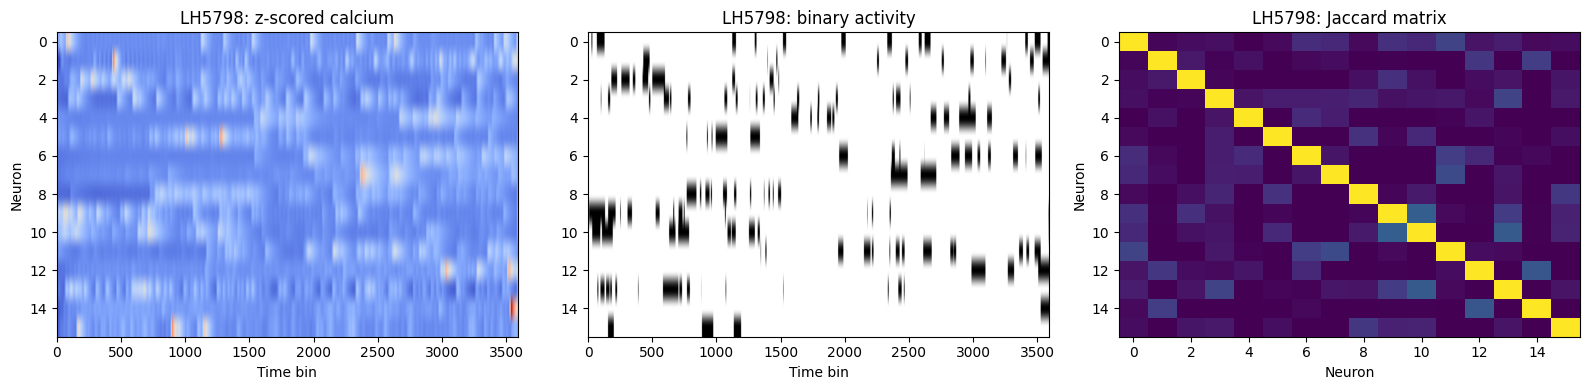

In [101]:
if last_preview is None:
    print('No processed mouse available for preview. Check skipped_mice_df for exclusion reasons.')
else:
    miceID = last_preview['miceID']
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].imshow(last_preview['TST_data'].T, aspect='auto', cmap='coolwarm')
    axes[0].set_title(f'{miceID}: z-scored calcium')
    axes[0].set_xlabel('Time bin')
    axes[0].set_ylabel('Neuron')

    axes[1].imshow(last_preview['binary_data'].T, aspect='auto', cmap='gray_r')
    axes[1].set_title(f'{miceID}: binary activity')
    axes[1].set_xlabel('Time bin')

    axes[2].imshow(last_preview['jaccard_matrix'], aspect='auto', cmap=jaccard_cmap, vmin=0, vmax=1)
    axes[2].set_title(f'{miceID}: Jaccard matrix')
    axes[2].set_xlabel('Neuron')
    axes[2].set_ylabel('Neuron')

    plt.tight_layout()
    plt.show()
